[GOTFlow] ep    0/200  OT=0.00473815
[GOTFlow] ep   25/200  OT=0.0047355
[GOTFlow] ep   50/200  OT=0.00473248
[GOTFlow] ep   75/200  OT=0.00472646
[GOTFlow] ep  100/200  OT=0.00472348
[GOTFlow] ep  125/200  OT=0.00471965
[GOTFlow] ep  150/200  OT=0.00471517
[GOTFlow] ep  175/200  OT=0.00470914
[GOTFlow] ep  199/200  OT=0.00470518


/home/u5501929/Nextcloud/Clustering_TSR/Github_Repo_GOTFlow/gotflow.py:665: RuntimeWarning: overflow encountered in cast
  "v": v.astype(np.float32, copy=False),


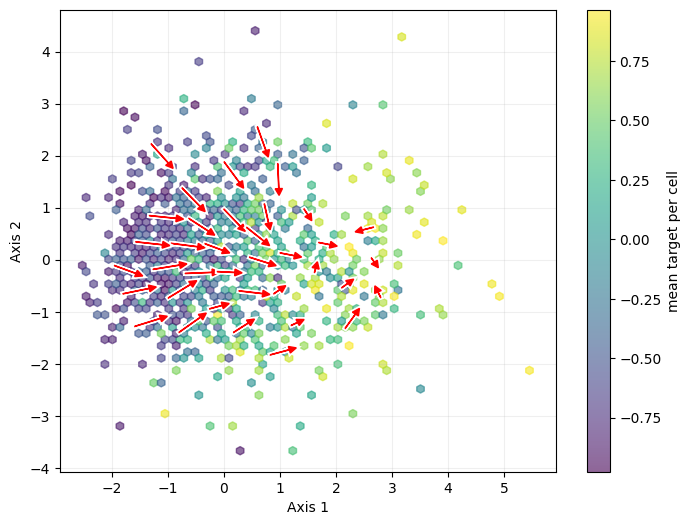

In [1]:
from __future__ import annotations

import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import util_functions as util

from gotflow import GOTFlow

#---------------------------------------------------------------------------------------
#---------------------Fit GOTFlow on the breast cancer risk dataset---------------------
#---------------------------------------------------------------------------------------



RISK_CSV = "Datasets/TSURE_Risk_BRCA.csv"
SURV_XLSX = "./Datasets/TCGA-CDR-SupplementalTableS1.csv"

# Load data
data = pd.read_csv(RISK_CSV)
data.set_index("SAMPLE_ID", inplace=True)

gene_cols = [c for c in data.columns if c not in ["SAMPLE_ID", "Risk"]]
X_gene = data[gene_cols].to_numpy(dtype=float)

# standardise genes
X_gene = StandardScaler().fit_transform(X_gene)

# bin by risk quantiles (invert if you want bin0=lowest risk)
target='Risk'
t = -data[target].to_numpy()
K = 5
state_ids, _ = GOTFlow.quantile_bin(t, K=K)

# ---- learnable representation phi (start here; later you can swap your encoder) ----
d_in = X_gene.shape[1]
d_out = 32

phi = GOTFlow.make_mlp(d_in=d_in, d_out=d_out, hidden=32, depth=2)

got = GOTFlow(
    blur=0.5,        # OT smoothing (eps ~ blur^2)
    scaling=0.9,
    reach=0.01,      # smaller reach => closer to balanced OT
    phi=phi,
    debias=True,     # Sinkhorn divergence (less biased than raw entropic cost)
)

got.fit(
    X_gene,
    state_ids,
    learn_phi=True,
    epochs=200,
    lr=1e-5,
    weight_decay=1e-2,
    drift_mode="barycentric",  # important: makes plan-based analysis consistent
    sinkhorn_max_iter=1000,
    sinkhorn_tol=1e-6,
    transition_fit=False
)

#Projection into 2D and Plotting
Z2, V2 = got.project_pls(n_components=2, standardize=True)
km = KMeans(n_clusters=50, n_init="auto", random_state=0)
cid = km.fit_predict(Z2)
P, U, counts, labs = GOTFlow.cluster_average(Z2, V2, cid, min_points=10)

got.plot_quiver(Z2, t, P, U, title=f"GOTFlow - Learn phi - K={K}")


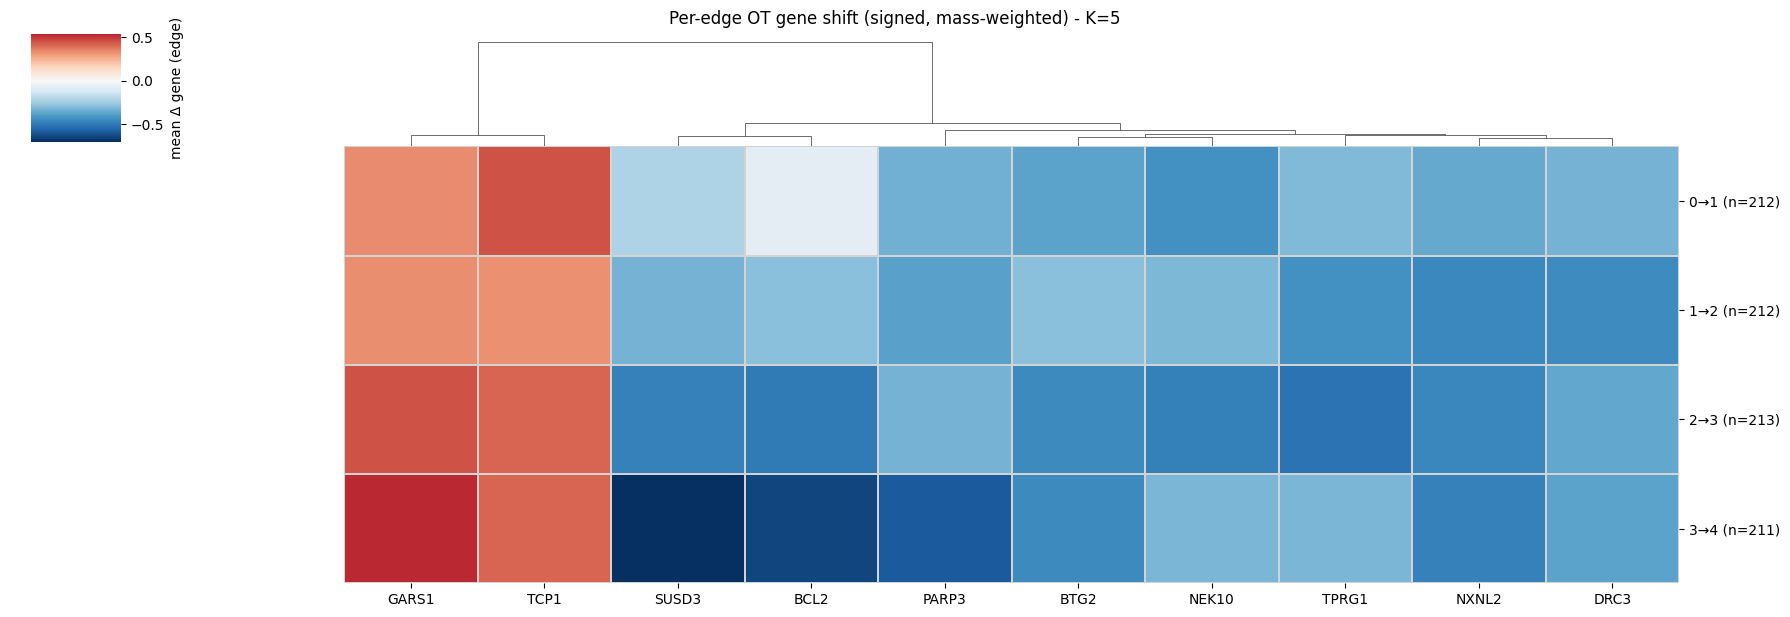

In [2]:

#---------------------------------------------------------------------------------------
#------------------Per-edge gene shift heatmap (EDGE plot: K-1 rows)--------------------
#---------------------------------------------------------------------------------------

top_n_genes = 10 # Number of genes to show in the heatmap (per edge)

heat, edge_df, top_list=util.edge_shift_heatmap(
    got=got,
    X_gene=X_gene,
    gene_cols=gene_cols,
    state_ids=state_ids,
    top_genes=top_n_genes,
    aggregate="mean",
    signed=True,
    weight_by_mass=True,
    title=f"Per-edge OT gene shift (signed, mass-weighted) - K={K}",
)


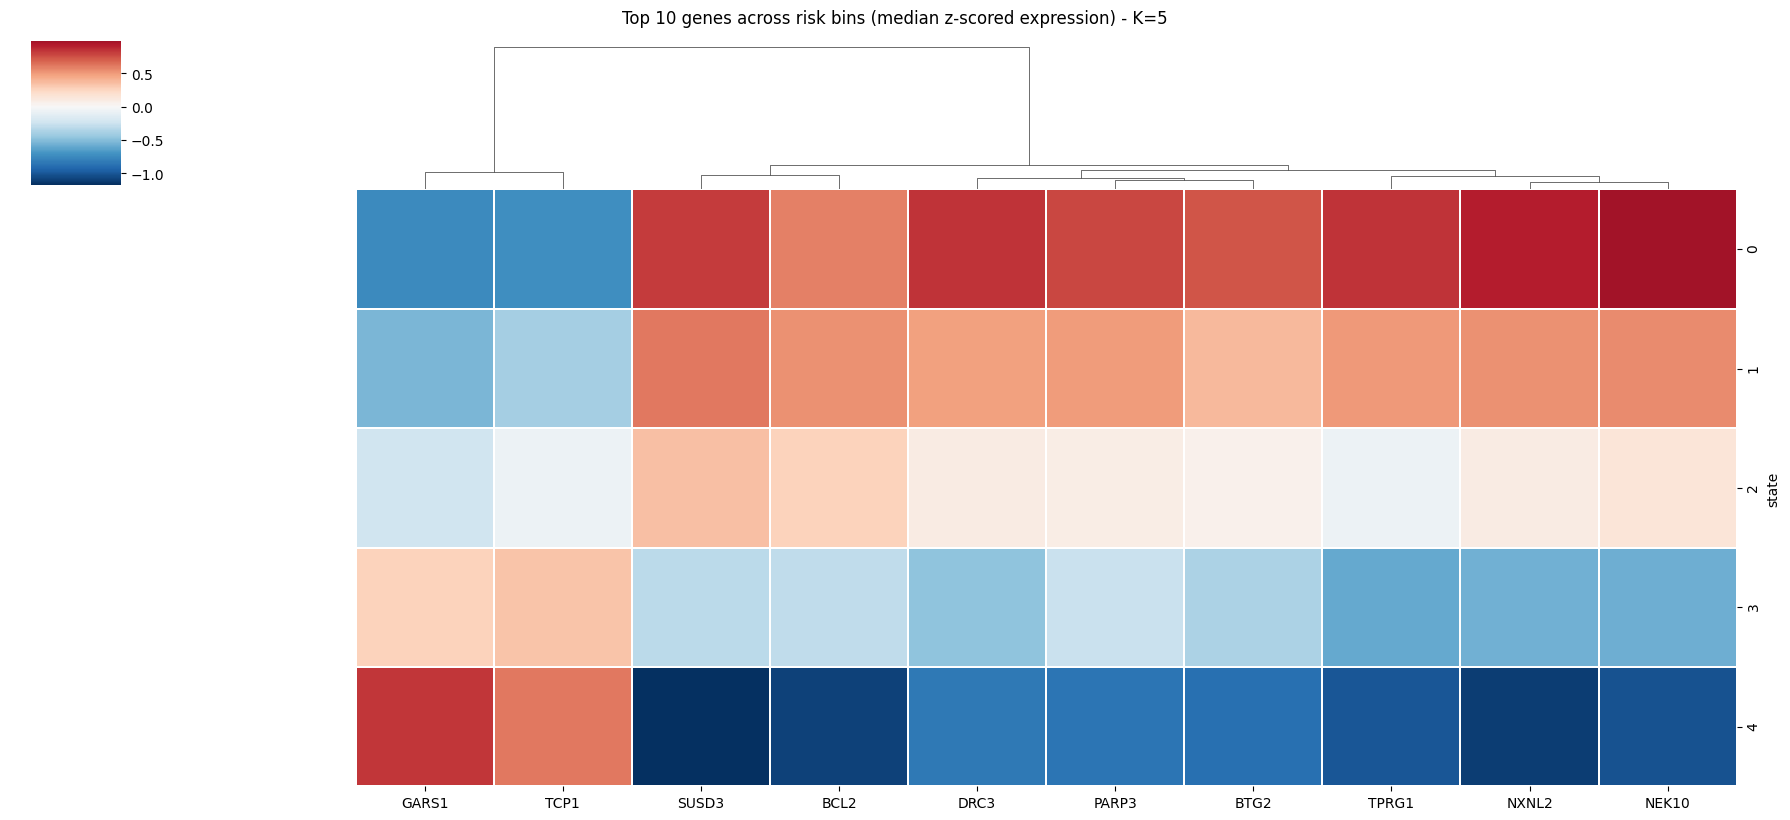

In [3]:

#---------------------------------------------------------------------------------------
#-------------------------Top gene expression patterns heatmap--------------------------
#---------------------------------------------------------------------------------------

Xstd_df = pd.DataFrame(X_gene, columns=gene_cols)
Xstd_top = Xstd_df[top_list]

heat = util.heatmap_top_features_by_state(
    values=Xstd_top,
    state_ids=state_ids,
    top_n=None,          # IMPORTANT: don’t re-select
    grouping="median",
    row_cluster=False,   # optional: keep same row order
    title=f"Top {top_n_genes} genes across risk bins (median z-scored expression) - K={K}",
    
)

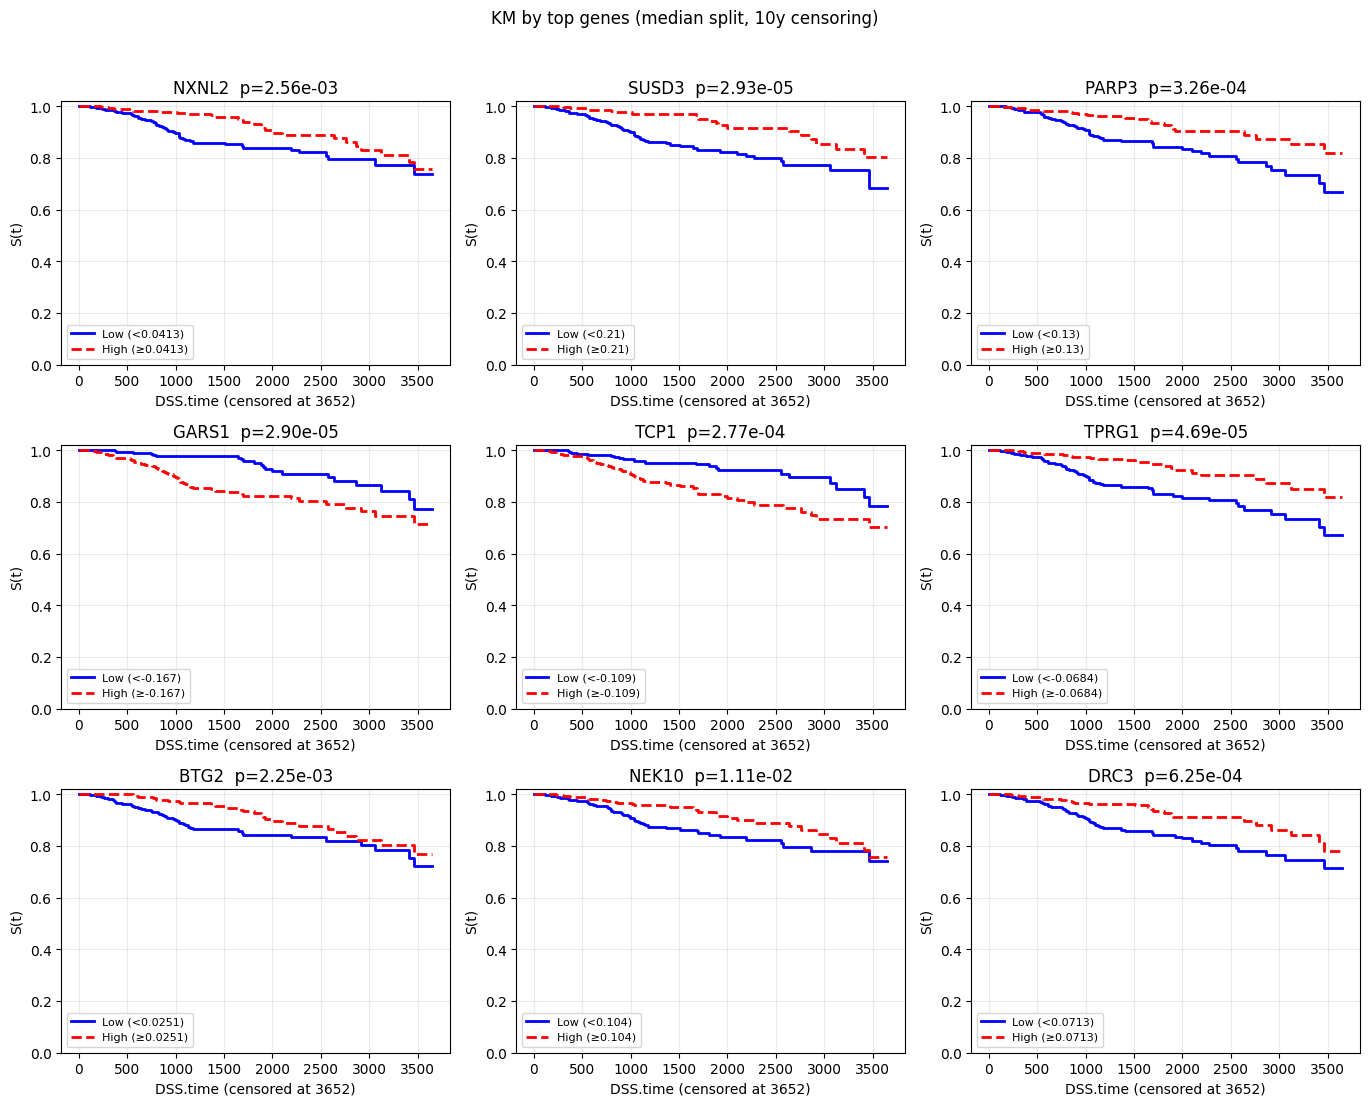

In [4]:

#---------------------------------------------------------------------------------------
#-----------------------------KMs for the top genes-------------------------------------
#---------------------------------------------------------------------------------------

# Fetch survival data
time = "DSS.time"
event = "DSS"

df_survival = pd.read_csv(SURV_XLSX)
df_survival = df_survival.loc[:, ['bcr_patient_barcode', time, event]]
df_survival.set_index('bcr_patient_barcode', inplace=True)
df_survival.index.set_names('SAMPLE_ID', inplace=True)
dataset = data.join(df_survival, on='SAMPLE_ID', how='inner')


genes_set = top_list[:9] 

fig, axes, res = util.plot_km_grid_by_gene(
    df=dataset,                 # <- IMPORTANT: use the joined dataset that contains survival cols
    genes_set=genes_set,
    time_col=time,           
    event_col=event,           
    split="median",
    censor_time=3652,
    min_group_n=20,
    ncols=3,
    show_at_risk=False,
    suptitle="KM by top genes (median split, 10y censoring)",
)


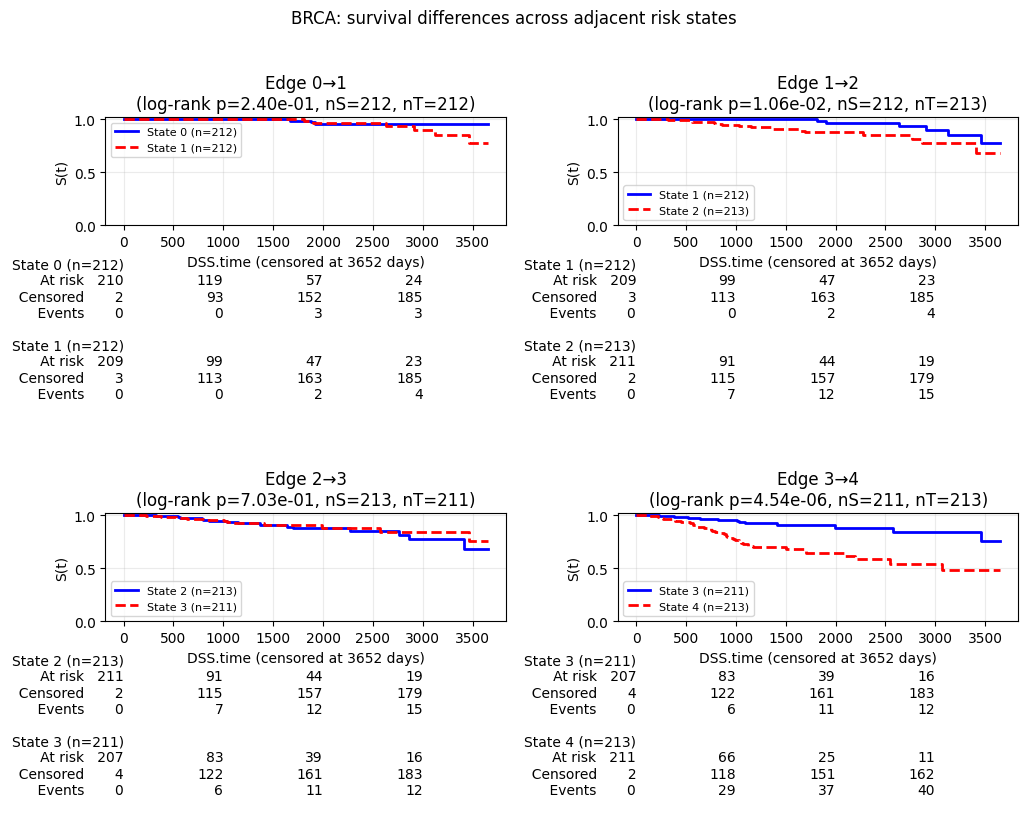

In [5]:
#---------------------------------------------------------------------------------------
#---------------------------------KMs per-edge------------------------------------------
#---------------------------------------------------------------------------------------


fig, axes, edge_stats = util.plot_km_subplots_per_edge(
    df=dataset,           # must contain Time, Event
    state_ids=state_ids,       # your risk-bin assignments (states)
    time_col=time,
    event_col=event,
    censor_time=3652,        # 10 years
    ncols=2,
    min_group_n=25,
    suptitle=f"BRCA: survival differences across adjacent risk states",
)



    gene     n        HR      coef  CI95_low  CI95_high             p status  \
1  SUSD3  1061  0.594077 -0.520746  0.482250   0.731836  9.876818e-07     ok   
4   TCP1  1061  1.633138  0.490504  1.335619   1.996933  1.749964e-06     ok   
0  NXNL2  1061  0.596156 -0.517253  0.479764   0.740786  3.050516e-06     ok   
2  PARP3  1061  0.648056 -0.433777  0.537093   0.781945  5.984172e-06     ok   
5  TPRG1  1061  0.602623 -0.506464  0.475846   0.763175  2.638081e-05     ok   
6   BTG2  1061  0.630183 -0.461745  0.507663   0.782272  2.837750e-05     ok   
3  GARS1  1061  1.447290  0.369693  1.215369   1.723468  3.340897e-05     ok   
8   DRC3  1061  0.644583 -0.439151  0.520048   0.798941  6.090603e-05     ok   
7  NEK10  1061  0.672484 -0.396778  0.542112   0.834209  3.078783e-04     ok   
9   BCL2  1061  0.692363 -0.367644  0.559197   0.857242  7.427356e-04     ok   

          q  
1  0.000009  
4  0.000009  
0  0.000010  
2  0.000015  
5  0.000047  
6  0.000047  
3  0.000048  
8  0.00

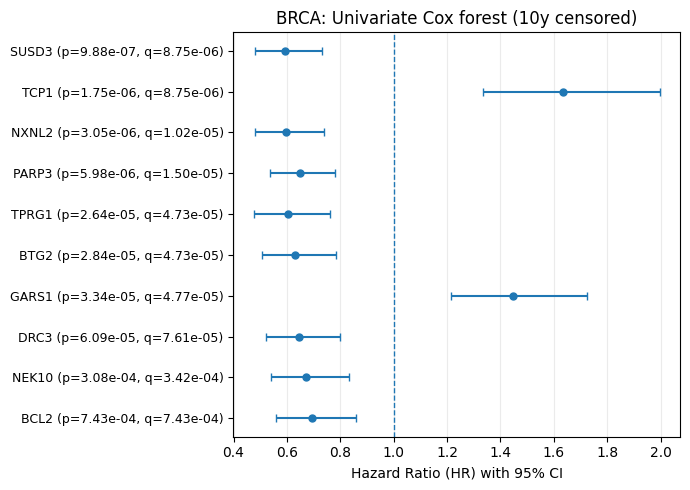

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'BRCA: Univariate Cox forest (10y censored)'}, xlabel='Hazard Ratio (HR) with 95% CI'>)

In [6]:

#---------------------------------------------------------------------------------------
#------------------------------Univariate Analysis--------------------------------------
#---------------------------------------------------------------------------------------


from lifelines import CoxPHFitter

cox_tbl = util.cox_univariate_top_genes(
    df=dataset,
    genes=top_list,
    time_col=time,        
    event_col=event,      
    censor_time=3652,     # 10 years
    standardize=True,
    min_n=25,
)

print(cox_tbl.head(20))

util.plot_cox_forest(
    cox_tbl,
    max_genes=20,
    sort_by="p",
    only_significant=False,     # set True to show only significant genes
    q_thresh=0.05,
    title=f"BRCA: Univariate Cox forest (10y censored)",
    figsize=(7, 5),
    show_q=True,
)



